In [ ]:
!pip install -q transformers accelerate scipy pandas

In [ ]:
import torch
import numpy as np
import pandas as pd

from scipy.spatial.distance import cosine

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

In [ ]:
qwen_id = "Qwen/Qwen1.5-1.8B-Chat"

print("Loading Qwen tokenizer...")

qwen_tokenizer = AutoTokenizer.from_pretrained(
    qwen_id
)

print("Loading Qwen model...")

qwen_model = AutoModelForCausalLM.from_pretrained(
    qwen_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("Qwen loaded successfully.")

Loading Qwen tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.67G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

Qwen loaded successfully.


In [ ]:
masters_dataset = [

    {
        "id": 1,

        "concept": "Giri",

        "E_base":
        "I attended my colleague's event because I wanted to support them personally.",

        "J_asym":
        "同僚との関係を保つために、私は義理としてその行事に出席した。",

        "E_lit":
        "To maintain my relationship with my colleague, I attended the event as a social obligation.",

        "S_sym":
        "Asistí al evento de mi colega porque quería apoyarlo personalmente."
    },

    {
        "id": 2,

        "concept": "Wa",

        "E_base":
        "The team agreed with the manager to maintain harmony during the meeting.",

        "J_asym":
        "会議では和を乱さないよう全員が部長の意見に合わせた。",

        "E_lit":
        "Everyone aligned with the manager's opinion so harmony would not be disturbed during the meeting.",

        "S_sym":
        "El equipo estuvo de acuerdo con el gerente para mantener la armonía durante la reunión."
    },

    {
        "id": 3,

        "concept": "Ikigai",

        "E_base":
        "I feel motivated because my work gives me a strong sense of purpose.",

        "J_asym":
        "毎日の仕事に生きがいを感じている。",

        "E_lit":
        "I feel ikigai and purpose in my daily work.",

        "S_sym":
        "Me siento motivado porque mi trabajo me da un fuerte sentido de propósito."
    }

]

print("Qwen control dataset initialized.")

Qwen control dataset initialized.


In [ ]:
def extract_pooled_hidden_states(
    text,
    model,
    tokenizer,
    scramble=False
):

    if scramble:

        raw_ids = tokenizer.encode(
            text,
            add_special_tokens=False
        )

        random.shuffle(raw_ids)

        if tokenizer.bos_token_id is not None:

            input_ids = [
                [tokenizer.bos_token_id] + raw_ids
            ]

        else:

            input_ids = [raw_ids]

        inputs = {
            "input_ids": torch.tensor(
                input_ids
            ).to(model.device)
        }

    else:

        inputs = tokenizer(
            text,
            return_tensors="pt"
        ).to(model.device)

    with torch.no_grad():

        outputs = model(
            **inputs,
            output_hidden_states=True
        )

    pooled_layers = []

    for layer in outputs.hidden_states:

        pooled_vector = torch.mean(
            layer[0],
            dim=0
        )

        pooled_layers.append(
            pooled_vector
            .detach()
            .cpu()
            .to(torch.float32)
            .numpy()
        )

    return np.array(pooled_layers)

print("Corrected Qwen extraction pipeline ready.")

Corrected Qwen extraction pipeline ready.


In [ ]:
qwen_records = []

print("Beginning Qwen controlled manifold audit...\n")

for triplet in masters_dataset:

    print(f"Processing Concept: {triplet['concept']}")

    v_base = extract_pooled_hidden_states(
        triplet["E_base"],
        qwen_model,
        qwen_tokenizer
    )

    v_asym = extract_pooled_hidden_states(
        triplet["J_asym"],
        qwen_model,
        qwen_tokenizer
    )

    v_lit = extract_pooled_hidden_states(
        triplet["E_lit"],
        qwen_model,
        qwen_tokenizer
    )

    v_sym = extract_pooled_hidden_states(
        triplet["S_sym"],
        qwen_model,
        qwen_tokenizer
    )

    v_scram = extract_pooled_hidden_states(
        triplet["J_asym"],
        qwen_model,
        qwen_tokenizer,
        scramble=True
    )

    num_layers = v_base.shape[0]

    for layer_idx in range(num_layers):

        d_asym = cosine(
            v_asym[layer_idx],
            v_base[layer_idx]
        )

        d_lit = cosine(
            v_lit[layer_idx],
            v_base[layer_idx]
        )

        d_sym = cosine(
            v_sym[layer_idx],
            v_base[layer_idx]
        )

        d_scram = cosine(
            v_scram[layer_idx],
            v_base[layer_idx]
        )

        qwen_records.append({

            "concept": triplet["concept"],

            "layer": layer_idx,

            "dist_asym": d_asym,

            "dist_lit": d_lit,

            "dist_sym": d_sym,

            "dist_scram": d_scram
        })

print("\nQwen controlled audit completed.")

Beginning Qwen controlled manifold audit...

Processing Concept: Giri
Processing Concept: Wa
Processing Concept: Ikigai

Qwen controlled audit completed.


In [ ]:
df_qwen = pd.DataFrame(qwen_records)

print(df_qwen.head())

  concept  layer  dist_asym  dist_lit  dist_sym  dist_scram
0    Giri      0   0.894774  0.204510  0.623324    0.894774
1    Giri      1   0.292406  0.064905  0.159871    0.368108
2    Giri      2   0.124231  0.017884  0.060959    0.172858
3    Giri      3   0.121817  0.013791  0.046025    0.167895
4    Giri      4   0.089670  0.012404  0.045921    0.111813


In [ ]:
qwen_summary = df_qwen.groupby("layer")[[
    "dist_asym",
    "dist_lit",
    "dist_sym",
    "dist_scram"
]].mean().reset_index()

print(qwen_summary)

    layer  dist_asym  dist_lit  dist_sym  dist_scram
0       0   0.876217  0.222696  0.650371    0.876217
1       1   0.373281  0.066773  0.206591    0.399323
2       2   0.137802  0.017234  0.069976    0.163839
3       3   0.137212  0.013201  0.053140    0.153671
4       4   0.102199  0.012976  0.051126    0.109697
5       5   0.104046  0.016796  0.066939    0.114841
6       6   0.115660  0.031341  0.082752    0.147497
7       7   0.003774  0.000849  0.003225    0.004098
8       8   0.004227  0.000950  0.003108    0.004774
9       9   0.005155  0.001302  0.003671    0.005907
10     10   0.006272  0.001714  0.004372    0.007407
11     11   0.007986  0.002388  0.004880    0.008913
12     12   0.009986  0.002893  0.005892    0.011162
13     13   0.012539  0.003883  0.007970    0.013951
14     14   0.017039  0.005161  0.010235    0.019107
15     15   0.024683  0.007311  0.014328    0.027431
16     16   0.044158  0.010994  0.022012    0.047618
17     17   0.058340  0.015329  0.029242    0.

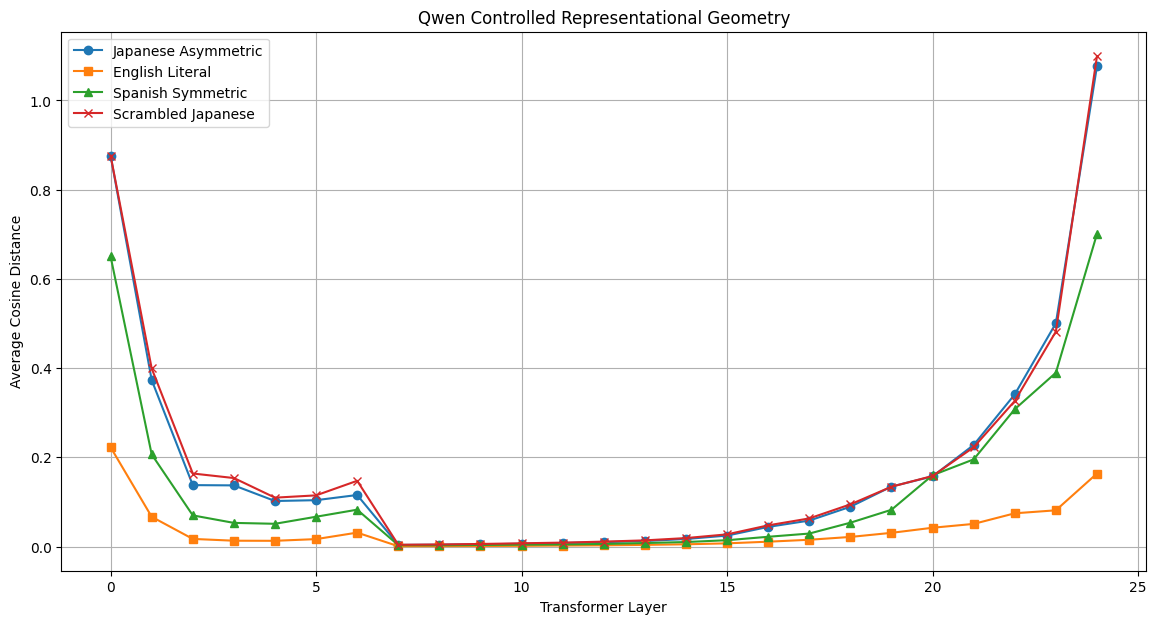

In [ ]:
plt.figure(figsize=(14, 7))

plt.plot(
    qwen_summary["layer"],
    qwen_summary["dist_asym"],
    marker='o',
    label="Japanese Asymmetric"
)

plt.plot(
    qwen_summary["layer"],
    qwen_summary["dist_lit"],
    marker='s',
    label="English Literal"
)

plt.plot(
    qwen_summary["layer"],
    qwen_summary["dist_sym"],
    marker='^',
    label="Spanish Symmetric"
)

plt.plot(
    qwen_summary["layer"],
    qwen_summary["dist_scram"],
    marker='x',
    label="Scrambled Japanese"
)

plt.xlabel("Transformer Layer")

plt.ylabel("Average Cosine Distance")

plt.title(
    "Qwen Controlled Representational Geometry"
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
df_qwen.to_csv(
    "qwen_control_results.csv",
    index=False
)

qwen_summary.to_csv(
    "qwen_control_summary.csv",
    index=False
)

print("Qwen results saved.")

Qwen results saved.


In [ ]:
df_tiny = pd.read_csv(
    "tinyllama_control_results.csv"
)

df_qwen = pd.read_csv(
    "qwen_control_results.csv"
)

df_tiny["model"] = "TinyLlama-1.1B"

df_qwen["model"] = "Qwen-1.8B"

df_regen = pd.concat(
    [df_tiny, df_qwen],
    ignore_index=True
)

print(df_regen.head())

  concept  layer  dist_asym  dist_lit  dist_sym  dist_scram           model
0    Giri      0   0.893528  0.302654  0.710135    0.893528  TinyLlama-1.1B
1    Giri      1   0.221083  0.040744  0.110772    0.223149  TinyLlama-1.1B
2    Giri      2   0.189613  0.035925  0.115481    0.205848  TinyLlama-1.1B
3    Giri      3   0.004979  0.000434  0.000990    0.004370  TinyLlama-1.1B
4    Giri      4   0.009494  0.000789  0.001697    0.008438  TinyLlama-1.1B


In [ ]:
import numpy as np

In [ ]:
def calculate_cohens_d(x, y):

    nx = len(x)
    ny = len(y)

    dof = nx + ny - 2

    pooled_std = np.sqrt(

        (
            (nx - 1) * np.var(x, ddof=1)
            +
            (ny - 1) * np.var(y, ddof=1)
        ) / dof
    )

    d = (
        np.mean(x)
        -
        np.mean(y)
    ) / pooled_std

    return d

print("Cohen's d function compiled.")

Cohen's d function compiled.


In [ ]:
tiny_zone = df_regen[

    (df_regen["model"] == "TinyLlama-1.1B")

    &

    (df_regen["layer"].between(11, 18))

]

qwen_zone = df_regen[

    (df_regen["model"] == "Qwen-1.8B")

    &

    (df_regen["layer"].between(12, 20))

]

print("Semantic zones isolated.")

Semantic zones isolated.


In [ ]:
tiny_asym_vs_lit = calculate_cohens_d(

    tiny_zone["dist_asym"],

    tiny_zone["dist_lit"]

)

tiny_asym_vs_sym = calculate_cohens_d(

    tiny_zone["dist_asym"],

    tiny_zone["dist_sym"]

)

tiny_asym_vs_scram = calculate_cohens_d(

    tiny_zone["dist_asym"],

    tiny_zone["dist_scram"]

)

print("=== TINYLLAMA EFFECT SIZES ===\n")

print(
    f"Asym vs Literal : {tiny_asym_vs_lit:.4f}"
)

print(
    f"Asym vs Spanish : {tiny_asym_vs_sym:.4f}"
)

print(
    f"Asym vs Scrambled : {tiny_asym_vs_scram:.4f}"
)

=== TINYLLAMA EFFECT SIZES ===

Asym vs Literal : 2.1495
Asym vs Spanish : 1.8137
Asym vs Scrambled : -0.6972


In [ ]:
qwen_asym_vs_lit = calculate_cohens_d(

    qwen_zone["dist_asym"],

    qwen_zone["dist_lit"]

)

qwen_asym_vs_sym = calculate_cohens_d(

    qwen_zone["dist_asym"],

    qwen_zone["dist_sym"]

)

qwen_asym_vs_scram = calculate_cohens_d(

    qwen_zone["dist_asym"],

    qwen_zone["dist_scram"]

)

print("=== QWEN EFFECT SIZES ===\n")

print(
    f"Asym vs Literal : {qwen_asym_vs_lit:.4f}"
)

print(
    f"Asym vs Spanish : {qwen_asym_vs_sym:.4f}"
)

print(
    f"Asym vs Scrambled : {qwen_asym_vs_scram:.4f}"

)

=== QWEN EFFECT SIZES ===

Asym vs Literal : 1.0974
Asym vs Spanish : 0.3385
Asym vs Scrambled : -0.0420


In [ ]:
test_vectors = extract_pooled_hidden_states(

    masters_dataset[0]["J_asym"],

    qwen_model,

    qwen_tokenizer

)

print(test_vectors.shape)

(25, 2048)


In [ ]:
tiny_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

print("Loading TinyLlama tokenizer...")

tiny_tokenizer = AutoTokenizer.from_pretrained(
    tiny_id
)

print("Loading TinyLlama model...")

tiny_model = AutoModelForCausalLM.from_pretrained(
    tiny_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("TinyLlama loaded successfully.")

Loading TinyLlama tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading TinyLlama model...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

TinyLlama loaded successfully.


PILOT DATASET CONSTRUCTION

In [ ]:
dataset = []

In [ ]:
masters_dataset = [

    {
        "id": 1,

        "concept": "Giri",

        "E_base":
        "I attended my colleague's event because I wanted to support them personally.",

        "J_asym":
        "同僚との関係を保つために、私は義理としてその行事に出席した。",

        "E_lit":
        "To maintain my relationship with my colleague, I attended the event as a social obligation.",

        "S_sym":
        "Asistí al evento de mi colega porque quería apoyarlo personalmente."
    },

    {
        "id": 2,

        "concept": "Wa",

        "E_base":
        "The team agreed with the manager to maintain harmony during the meeting.",

        "J_asym":
        "会議では和を乱さないよう全員が部長の意見に合わせた。",

        "E_lit":
        "Everyone aligned with the manager's opinion so harmony would not be disturbed during the meeting.",

        "S_sym":
        "El equipo estuvo de acuerdo con el gerente para mantener la armonía durante la reunión."
    },

    {
        "id": 3,

        "concept": "Ikigai",

        "E_base":
        "I feel motivated because my work gives me a strong sense of purpose.",

        "J_asym":
        "毎日の仕事に生きがいを感じている。",

        "E_lit":
        "I feel ikigai and purpose in my daily work.",

        "S_sym":
        "Me siento motivado porque mi trabajo me da un fuerte sentido de propósito."
    }

]

print("Mini control dataset initialized.")

Mini control dataset initialized.


In [ ]:
def extract_pooled_hidden_states(
    text,
    model,
    tokenizer,
    scramble=False
):

    if scramble:

        raw_ids = tokenizer.encode(
            text,
            add_special_tokens=False
        )

        random.shuffle(raw_ids)

        inputs = {
            "input_ids": torch.tensor(
                [[tokenizer.bos_token_id] + raw_ids]
            ).to(model.device)
        }

    else:

        inputs = tokenizer(
            text,
            return_tensors="pt"
        ).to(model.device)

    with torch.no_grad():

        outputs = model(
            **inputs,
            output_hidden_states=True
        )

    pooled_layers = []

    for layer in outputs.hidden_states:

        pooled_vector = torch.mean(
            layer[0],
            dim=0
        )

        pooled_layers.append(
            pooled_vector
            .detach()
            .cpu()
            .to(torch.float32)
            .numpy()
        )

    return np.array(pooled_layers)

print("Control extraction pipeline ready.")

Control extraction pipeline ready.


In [ ]:
test_vectors = extract_pooled_hidden_states(

    masters_dataset[0]["J_asym"],

    tiny_model,

    tiny_tokenizer

)

print(test_vectors.shape)

(23, 2048)


In [ ]:
master_records = []

print("Beginning controlled manifold audit...\n")

for triplet in masters_dataset:

    print(f"Processing Concept: {triplet['concept']}")

    v_base = extract_pooled_hidden_states(
        triplet["E_base"],
        tiny_model,
        tiny_tokenizer
    )

    v_asym = extract_pooled_hidden_states(
        triplet["J_asym"],
        tiny_model,
        tiny_tokenizer
    )

    v_lit = extract_pooled_hidden_states(
        triplet["E_lit"],
        tiny_model,
        tiny_tokenizer
    )

    v_sym = extract_pooled_hidden_states(
        triplet["S_sym"],
        tiny_model,
        tiny_tokenizer
    )

    v_scram = extract_pooled_hidden_states(
        triplet["J_asym"],
        tiny_model,
        tiny_tokenizer,
        scramble=True
    )

    num_layers = v_base.shape[0]

    for layer_idx in range(num_layers):

        d_asym = cosine(
            v_asym[layer_idx],
            v_base[layer_idx]
        )

        d_lit = cosine(
            v_lit[layer_idx],
            v_base[layer_idx]
        )

        d_sym = cosine(
            v_sym[layer_idx],
            v_base[layer_idx]
        )

        d_scram = cosine(
            v_scram[layer_idx],
            v_base[layer_idx]
        )

        master_records.append({

            "concept": triplet["concept"],

            "layer": layer_idx,

            "dist_asym": d_asym,

            "dist_lit": d_lit,

            "dist_sym": d_sym,

            "dist_scram": d_scram
        })

print("\nControlled manifold audit completed.")

Beginning controlled manifold audit...

Processing Concept: Giri
Processing Concept: Wa
Processing Concept: Ikigai

Controlled manifold audit completed.


In [ ]:
df_controls = pd.DataFrame(master_records)

print(df_controls.head())

  concept  layer  dist_asym  dist_lit  dist_sym  dist_scram
0    Giri      0   0.893528  0.302654  0.710135    0.893528
1    Giri      1   0.221083  0.040744  0.110772    0.223149
2    Giri      2   0.189613  0.035925  0.115481    0.205848
3    Giri      3   0.004979  0.000434  0.000990    0.004370
4    Giri      4   0.009494  0.000789  0.001697    0.008438


In [ ]:
control_summary = df_controls.groupby("layer")[[
    "dist_asym",
    "dist_lit",
    "dist_sym",
    "dist_scram"
]].mean().reset_index()

print(control_summary)

    layer  dist_asym  dist_lit  dist_sym  dist_scram
0       0   0.895321  0.337333  0.696978    0.895321
1       1   0.228296  0.046326  0.123135    0.230233
2       2   0.197696  0.044395  0.113341    0.203912
3       3   0.003675  0.000509  0.001124    0.003373
4       4   0.006945  0.000909  0.001939    0.006392
5       5   0.011354  0.001628  0.003174    0.010969
6       6   0.018233  0.002560  0.004571    0.018669
7       7   0.028029  0.003674  0.006197    0.032415
8       8   0.038057  0.006272  0.009057    0.047638
9       9   0.046064  0.007741  0.010010    0.058972
10     10   0.059926  0.010406  0.013188    0.079766
11     11   0.070610  0.014169  0.015398    0.094204
12     12   0.084115  0.016219  0.018736    0.121167
13     13   0.097800  0.020535  0.023318    0.157130
14     14   0.118785  0.026595  0.028123    0.183240
15     15   0.139689  0.033523  0.033103    0.203740
16     16   0.187646  0.042965  0.057197    0.252129
17     17   0.225143  0.058710  0.072411    0.

In [ ]:
import matplotlib.pyplot as plt

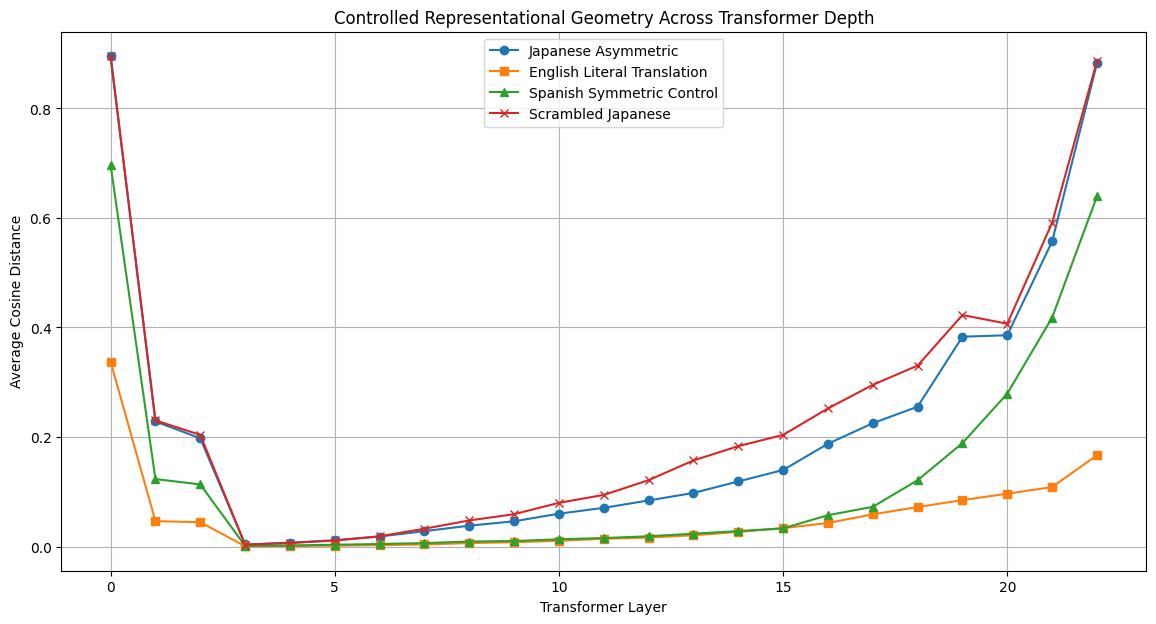

In [ ]:
plt.figure(figsize=(14, 7))

plt.plot(
    control_summary["layer"],
    control_summary["dist_asym"],
    marker='o',
    label="Japanese Asymmetric"
)

plt.plot(
    control_summary["layer"],
    control_summary["dist_lit"],
    marker='s',
    label="English Literal Translation"
)

plt.plot(
    control_summary["layer"],
    control_summary["dist_sym"],
    marker='^',
    label="Spanish Symmetric Control"
)

plt.plot(
    control_summary["layer"],
    control_summary["dist_scram"],
    marker='x',
    label="Scrambled Japanese"
)

plt.xlabel("Transformer Layer")

plt.ylabel("Average Cosine Distance")

plt.title(
    "Controlled Representational Geometry Across Transformer Depth"
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
df_controls.to_csv(
    "tinyllama_control_results.csv",
    index=False
)

control_summary.to_csv(
    "tinyllama_control_summary.csv",
    index=False
)

print("TinyLlama control results saved.")

TinyLlama control results saved.


In [ ]:
df_controls.to_csv(
    "controlled_geometry_results.csv",
    index=False
)

control_summary.to_csv(
    "controlled_geometry_summary.csv",
    index=False
)

print("Controlled geometry results saved.")


Controlled geometry results saved.


In [ ]:
import random

In [ ]:
from numpy import trapz

In [ ]:
auc_asym = trapz(
    control_summary["dist_asym"],
    control_summary["layer"]
)

auc_lit = trapz(
    control_summary["dist_lit"],
    control_summary["layer"]
)

auc_sym = trapz(
    control_summary["dist_sym"],
    control_summary["layer"]
)

auc_scram = trapz(
    control_summary["dist_scram"],
    control_summary["layer"]
)

print("=== AREA UNDER CURVE (AUC) ===\n")

print(f"Japanese Asymmetric : {auc_asym:.4f}")

print(f"English Literal     : {auc_lit:.4f}")

print(f"Spanish Symmetric   : {auc_sym:.4f}")

print(f"Scrambled Japanese  : {auc_scram:.4f}")

=== AREA UNDER CURVE (AUC) ===

Japanese Asymmetric : 4.0321
English Literal     : 0.9509
Spanish Symmetric   : 2.2094
Scrambled Japanese  : 4.6411


/tmp/ipykernel_13452/2173039121.py:1: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_asym = trapz(
/tmp/ipykernel_13452/2173039121.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_lit = trapz(
/tmp/ipykernel_13452/2173039121.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_sym = trapz(
/tmp/ipykernel_13452/2173039121.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_scram = trapz(


In [ ]:
import numpy as np

def bootstrap_layer_means(
    dataframe,
    metric_col,
    n_bootstrap=500
):

    layers = sorted(
        dataframe["layer"].unique()
    )

    boot_means = []

    for _ in range(n_bootstrap):

        sampled = dataframe.sample(
            frac=1,
            replace=True
        )

        layer_means = sampled.groupby(
            "layer"
        )[metric_col].mean().values

        boot_means.append(layer_means)

    boot_means = np.array(boot_means)

    lower = np.percentile(
        boot_means,
        2.5,
        axis=0
    )

    upper = np.percentile(
        boot_means,
        97.5,
        axis=0
    )

    mean = np.mean(
        boot_means,
        axis=0
    )

    return layers, mean, lower, upper

In [ ]:
layers, mean_asym, low_asym, high_asym = bootstrap_layer_means(
    df_controls,
    "dist_asym"
)

layers, mean_lit, low_lit, high_lit = bootstrap_layer_means(
    df_controls,
    "dist_lit"
)

layers, mean_sym, low_sym, high_sym = bootstrap_layer_means(
    df_controls,
    "dist_sym"
)

layers, mean_scram, low_scram, high_scram = bootstrap_layer_means(
    df_controls,
    "dist_scram"
)

print("Bootstrap confidence intervals computed.")

Bootstrap confidence intervals computed.


In [ ]:
plt.figure(figsize=(14, 7))

# Japanese Asymmetric
plt.plot(
    layers,
    mean_asym,
    label="Japanese Asymmetric"
)

plt.fill_between(
    layers,
    low_asym,
    high_asym,
    alpha=0.2
)

# English Literal
plt.plot(
    layers,
    mean_lit,
    label="English Literal"
)

plt.fill_between(
    layers,
    low_lit,
    high_lit,
    alpha=0.2
)

# Spanish Symmetric
plt.plot(
    layers,
    mean_sym,
    label="Spanish Symmetric"
)

plt.fill_between(
    layers,
    low_sym,
    high_sym,
    alpha=0.2
)

# Scrambled Japanese
plt.plot(
    layers,
    mean_scram,
    label="Scrambled Japanese"
)

plt.fill_between(
    layers,
    low_scram,
    high_scram,
    alpha=0.2
)

plt.xlabel("Transformer Layer")

plt.ylabel("Cosine Divergence")

plt.title(
    "Bootstrapped Layerwise Representational Geometry"
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
def bootstrap_layer_means(
    dataframe,
    metric_col,
    n_bootstrap=500
):

    layers = sorted(
        dataframe["layer"].unique()
    )

    boot_means = []

    for _ in range(n_bootstrap):

        sampled = dataframe.sample(
            frac=1,
            replace=True
        )

        grouped = sampled.groupby(
            "layer"
        )[metric_col].mean()

        layer_means = []

        for layer in layers:

            if layer in grouped.index:

                layer_means.append(
                    grouped[layer]
                )

            else:

                layer_means.append(
                    np.nan
                )

        boot_means.append(layer_means)

    boot_means = np.array(
        boot_means,
        dtype=np.float32
    )

    lower = np.nanpercentile(
        boot_means,
        2.5,
        axis=0
    )

    upper = np.nanpercentile(
        boot_means,
        97.5,
        axis=0
    )

    mean = np.nanmean(
        boot_means,
        axis=0
    )

    return layers, mean, lower, upper

In [ ]:
dataset.append({

    "id": 1,

    "category": "Interpersonal Obligations",

    "concept": "Giri",

    "E_base":
    "I attended my colleague's event because I wanted to support them personally.",

    "J_asym":
    "義理のために同僚の行事に出席した。",

    "E_lit":
    "To maintain my relationship with my colleague, I attended the event as a social obligation."

})

In [ ]:
dataset[0]["J_asym"] = "義理のために同僚の行事に出席した。"

print(dataset[0])

{'id': 1, 'category': 'Interpersonal Obligations', 'concept': 'Giri', 'E_base': "I attended my colleague's event because I wanted to support them personally.", 'J_asym': '義理のために同僚の行事に出席した。', 'E_lit': 'To maintain my relationship with my colleague, I attended the event as a social obligation.'}


In [ ]:
print(dataset)

[{'id': 1, 'category': 'Interpersonal Obligations', 'concept': 'Giri', 'E_base': "I attended my colleague's event because I wanted to support them personally.", 'J_asym': '義理のために同僚の行事に出席した。', 'E_lit': 'To maintain my relationship with my colleague, I attended the event as a social obligation.'}, {'id': 3, 'category': 'Work Ethic', 'concept': 'Ganbaru', 'E_base': 'I continued working on the assignment because I wanted to improve my skills and finish the task well.', 'J_asym': '疲れていても頑張って仕事を続けた。', 'E_lit': 'Even though I was tired, I persisted and continued the work.'}]


In [ ]:
for item in dataset:

    len_E = len(tokenizer.encode(item["E_base"]))

    len_J = len(tokenizer.encode(item["J_asym"]))

    len_L = len(tokenizer.encode(item["E_lit"]))

    print(f"\nTriplet ID: {item['id']}")
    print(f"Concept: {item['concept']}")

    print(f"E_base Tokens : {len_E}")
    print(f"J_asym Tokens : {len_J}")
    print(f"E_lit  Tokens : {len_L}")


Triplet ID: 1
Concept: Giri
E_base Tokens : 17
J_asym Tokens : 23
E_lit  Tokens : 20

Triplet ID: 3
Concept: Ganbaru
E_base Tokens : 20
J_asym Tokens : 27
E_lit  Tokens : 15


In [ ]:
dataset[1]["E_base"] = "I openly shared my disagreement during the meeting because direct discussion helps the group make better decisions."

print(dataset[1]["E_base"])


I openly shared my disagreement during the meeting because direct discussion helps the group make better decisions.


In [ ]:
print(len(tokenizer.encode(dataset[1]["E_base"])))

20


In [ ]:
dataset.append({

    "id": 3,

    "category": "Work Ethic",

    "concept": "Ganbaru",

    "E_base":
    "I continued working on the assignment because I wanted to improve my skills and finish the task well.",

    "J_asym":
    "疲れていても頑張って仕事を続けた。",

    "E_lit":
    "Even though I was tired, I persisted and continued the work."

})

In [ ]:
item = dataset[2]

len_E = len(tokenizer.encode(item["E_base"]))
len_J = len(tokenizer.encode(item["J_asym"]))
len_L = len(tokenizer.encode(item["E_lit"]))

print(f"\nTriplet ID: {item['id']}")
print(f"Concept: {item['concept']}")

print(f"E_base Tokens : {len_E}")
print(f"J_asym Tokens : {len_J}")
print(f"E_lit  Tokens : {len_L}")


Triplet ID: 3
Concept: Ganbaru
E_base Tokens : 20
J_asym Tokens : 27
E_lit  Tokens : 15


In [ ]:
dataset.append({

    "id": 2,

    "category": "Social Harmony",

    "concept": "Wa",

    "E_base":
    "I openly shared my disagreement during the meeting because direct discussion helps the group make better decisions.",

    "J_asym":
    "和を守るために会議で反対意見を言わなかった。",

    "E_lit":
    "The team members agreed with the manager's proposal in order to preserve harmony during the public meeting."

})

In [ ]:
dataset[1]["J_asym"] = "和のために会議で反対しなかった。"

print(dataset[1])

{'id': 1, 'category': 'Interpersonal Obligations', 'concept': 'Giri', 'E_base': "I attended my colleague's event because I wanted to support them personally.", 'J_asym': '和のために会議で反対しなかった。', 'E_lit': 'To maintain my relationship with my colleague, I attended the event as a social obligation.'}


In [ ]:
item = dataset[3]

len_E = len(tokenizer.encode(item["E_base"]))
len_J = len(tokenizer.encode(item["J_asym"]))
len_L = len(tokenizer.encode(item["E_lit"]))

print(f"\nTriplet ID: {item['id']}")
print(f"Concept: {item['concept']}")

print(f"E_base Tokens : {len_E}")
print(f"J_asym Tokens : {len_J}")
print(f"E_lit  Tokens : {len_L}")


Triplet ID: 2
Concept: Wa
E_base Tokens : 23
J_asym Tokens : 28
E_lit  Tokens : 17


In [ ]:
dataset[3]["J_asym"] = "古い茶碗に侘寂を感じた。"

print(dataset[3])

{'id': 4, 'category': 'Aesthetics and Impermanence', 'concept': 'Wabi-Sabi', 'E_base': 'I repaired the old cup because I wanted it to look clean and complete again.', 'J_asym': '古い茶碗に侘寂を感じた。', 'E_lit': 'I felt the beauty of wabi-sabi in the cracks of the old tea bowl.'}


In [ ]:
item = dataset[3]

len_E = len(tokenizer.encode(item["E_base"]))
len_J = len(tokenizer.encode(item["J_asym"]))
len_L = len(tokenizer.encode(item["E_lit"]))

print(f"\nTriplet ID: {item['id']}")
print(f"Concept: {item['concept']}")

print(f"E_base Tokens : {len_E}")
print(f"J_asym Tokens : {len_J}")
print(f"E_lit  Tokens : {len_L}")


Triplet ID: 4
Concept: Wabi-Sabi
E_base Tokens : 18
J_asym Tokens : 20
E_lit  Tokens : 21


In [ ]:
dataset.append({

    "id": 4,

    "category": "Aesthetics and Impermanence",

    "concept": "Wabi-Sabi",

    "E_base":
    "I repaired the old cup because I wanted it to look clean and complete again.",

    "J_asym":
    "古い茶碗に侘寂を感じた。",

    "E_lit":
    "I felt the beauty of wabi-sabi in the cracks of the old tea bowl."

})

In [ ]:
print(dataset[3])

{'id': 4, 'category': 'Aesthetics and Impermanence', 'concept': 'Wabi-Sabi', 'E_base': 'I repaired the old cup because I wanted it to look clean and complete again.', 'J_asym': '古い茶碗の傷に侘寂の美しさを感じた。', 'E_lit': 'I felt the beauty of wabi-sabi in the cracks of the old tea bowl.'}


In [ ]:
for i, item in enumerate(dataset):

    print(f"Index Position: {i}")
    print(f"Triplet ID: {item['id']}")
    print(f"Concept: {item['concept']}")
    print("----------------------")

Index Position: 0
Triplet ID: 1
Concept: Giri
----------------------
Index Position: 1
Triplet ID: 2
Concept: Wa
----------------------
Index Position: 2
Triplet ID: 3
Concept: Ganbaru
----------------------


In [ ]:
dataset[1]["E_base"] = "I openly shared my disagreement during the meeting because direct discussion helps the group make better decisions."

print(dataset[1])

{'id': 1, 'category': 'Interpersonal Obligations', 'concept': 'Giri', 'E_base': 'I openly shared my disagreement during the meeting because direct discussion helps the group make better decisions.', 'J_asym': '和のために会議で反対しなかった。', 'E_lit': 'To maintain my relationship with my colleague, I attended the event as a social obligation.'}


In [ ]:
dataset.append({

    "id": 5,

    "category": "Hospitality and Deference",

    "concept": "Omotenashi",

    "E_base":
    "The hotel staff provided helpful service and responded politely to the guests.",

    "J_asym":
    "店員はおもてなしの心で客を迎えた。",

    "E_lit":
    "The staff welcomed the guests with a spirit of omotenashi."

})

In [ ]:
item = dataset[4]

len_E = len(tokenizer.encode(item["E_base"]))
len_J = len(tokenizer.encode(item["J_asym"]))
len_L = len(tokenizer.encode(item["E_lit"]))

print(f"\nTriplet ID: {item['id']}")
print(f"Concept: {item['concept']}")

print(f"E_base Tokens : {len_E}")
print(f"J_asym Tokens : {len_J}")
print(f"E_lit  Tokens : {len_L}")


Triplet ID: 5
Concept: Omotenashi
E_base Tokens : 15
J_asym Tokens : 19
E_lit  Tokens : 15


In [ ]:
def audit_triplet(item):

    len_E = len(tokenizer.encode(item["E_base"]))
    len_J = len(tokenizer.encode(item["J_asym"]))
    len_L = len(tokenizer.encode(item["E_lit"]))

    spread = max(len_E, len_J, len_L) - min(len_E, len_J, len_L)

    print("=" * 50)

    print(f"Triplet ID : {item['id']}")
    print(f"Concept    : {item['concept']}")

    print(f"E_base Tokens : {len_E}")
    print(f"J_asym Tokens : {len_J}")
    print(f"E_lit Tokens  : {len_L}")

    print(f"Token Spread  : {spread}")

    if spread <= 10:
        print("STATUS: ACCEPTABLE")
    else:
        print("STATUS: NEEDS REVISION")

In [ ]:
dataset.append({

    "id": 6,

    "category": "Interpersonal Obligations",

    "concept": "Ninjo",

    "E_base":
    "I followed the company policy even though I personally disagreed with the decision.",

    "J_asym":
    "人情では助けたかったが規則に従った。",

    "E_lit":
    "Emotionally I wanted to help, but I followed the rules."

})

In [ ]:
audit_triplet(dataset[5])

Triplet ID : 6
Concept    : Ninjo
E_base Tokens : 16
J_asym Tokens : 22
E_lit Tokens  : 15
Token Spread  : 7
STATUS: ACCEPTABLE


In [ ]:
dataset.append({

    "id": 7,

    "category": "Social Harmony",

    "concept": "Kuuki wo Yomu",

    "E_base":
    "I asked everyone directly what they thought before making the decision.",

    "J_asym":
    "空気を読んで会議で黙っていた。",

    "E_lit":
    "Reading the atmosphere, I remained silent during the meeting."

})

In [ ]:
audit_triplet(dataset[6])

Triplet ID : 7
Concept    : Kuuki wo Yomu
E_base Tokens : 13
J_asym Tokens : 21
E_lit Tokens  : 12
Token Spread  : 9
STATUS: ACCEPTABLE


In [ ]:
dataset.append({

    "id": 8,

    "category": "Work Ethic and Meaning",

    "concept": "Ikigai",

    "E_base":
    "I enjoy my hobbies because they help me relax after work and reduce stress.",

    "J_asym":
    "毎日の仕事に生きがいを感じている。",

    "E_lit":
    "I feel a strong sense of ikigai and purpose in my daily work."

})

In [ ]:
audit_triplet(dataset[7])
print(dataset[7]["E_lit"])

Triplet ID : 8
Concept    : Ikigai
E_base Tokens : 18
J_asym Tokens : 23
E_lit Tokens  : 17
Token Spread  : 6
STATUS: ACCEPTABLE
I feel a strong sense of ikigai and purpose in my daily work.


In [ ]:
dataset[7]["E_lit"] = "I feel a strong sense of ikigai and purpose in my daily work."

print(dataset[7]["E_lit"])

I feel a strong sense of ikigai and purpose in my daily work.


In [ ]:
print(len(tokenizer.encode(dataset[7]["E_lit"])))

17


In [ ]:
dataset.append({

    "id": 9,

    "category": "Aesthetics and Impermanence",

    "concept": "Mono no Aware",

    "E_base":
    "I felt sad when the vacation ended because I did not want the enjoyable experience to stop.",

    "J_asym":
    "桜が散るのを見て物の哀れを感じた。",

    "E_lit":
    "Watching the cherry blossoms fall, I felt mono no aware."

})

In [ ]:
audit_triplet(dataset[8])

Triplet ID : 9
Concept    : Mono no Aware
E_base Tokens : 19
J_asym Tokens : 23
E_lit Tokens  : 18
Token Spread  : 5
STATUS: ACCEPTABLE


In [ ]:
dataset.append({

    "id": 10,

    "category": "Social Harmony",

    "concept": "Tatemae",

    "E_base":
    "I honestly told my manager that I disagreed with the proposal during the discussion.",

    "J_asym":
    "建前として会議では賛成した。",

    "E_lit":
    "As a public façade, I agreed during the meeting."

})

In [ ]:
audit_triplet(dataset[9])

Triplet ID : 10
Concept    : Tatemae
E_base Tokens : 17
J_asym Tokens : 20
E_lit Tokens  : 13
Token Spread  : 7
STATUS: ACCEPTABLE


In [ ]:
dataset.append({

    "id": 11,

    "category": "Interpersonal Obligations",

    "concept": "Enryo",

    "E_base":
    "I accepted the offer immediately because I was comfortable expressing my preference.",

    "J_asym":
    "遠慮して誘いを断った。",

    "E_lit":
    "Out of restraint, I declined the invitation."

})

dataset.append({

    "id": 12,

    "category": "Social Harmony",

    "concept": "Honne",

    "E_base":
    "I openly expressed my real opinion during the conversation with the group.",

    "J_asym":
    "本音は言わずに笑顔で答えた。",

    "E_lit":
    "Without saying my true feelings, I responded with a smile."

})

dataset.append({

    "id": 13,

    "category": "Work Ethic",

    "concept": "Shokunin Kishitsu",

    "E_base":
    "The worker carefully improved the product to achieve higher technical quality.",

    "J_asym":
    "職人の精神で丁寧に作った。",

    "E_lit":
    "With a craftsman's spirit, the details were finished carefully."

})

dataset.append({

    "id": 14,

    "category": "Aesthetics and Impermanence",

    "concept": "Yugen",

    "E_base":
    "The landscape looked beautiful because the mountains were visible in the distance.",

    "J_asym":
    "霧の山に幽玄な美しさを感じた。",

    "E_lit":
    "I felt a mysterious subtle beauty in the misty mountains."

})

dataset.append({

    "id": 15,

    "category": "Hospitality and Deference",

    "concept": "Senpai-Kohai",

    "E_base":
    "The senior employee gave advice to the younger worker during training.",

    "J_asym":
    "先輩として後輩を教えた。",

    "E_lit":
    "As a senior, I carefully guided the junior member."

})

In [ ]:
dataset[12]["J_asym"] = "職人の精神で丁寧に作った。"

dataset[14]["J_asym"] = "先輩として後輩を教えた。"

print("Triplets 13 and 15 updated.")

Triplets 13 and 15 updated.


In [ ]:
audit_triplet(dataset[12])

audit_triplet(dataset[14])

Triplet ID : 13
Concept    : Shokunin Kishitsu
E_base Tokens : 13
J_asym Tokens : 19
E_lit Tokens  : 16
Token Spread  : 6
STATUS: ACCEPTABLE
Triplet ID : 15
Concept    : Senpai-Kohai
E_base Tokens : 13
J_asym Tokens : 18
E_lit Tokens  : 12
Token Spread  : 6
STATUS: ACCEPTABLE


In [ ]:
dataset.append({

    "id": 16,

    "category": "Interpersonal Obligations",

    "concept": "Amae",

    "E_base":
    "I asked my friend directly for help because I trusted their support.",

    "J_asym":
    "甘えて友人に頼った。",

    "E_lit":
    "Depending emotionally, I relied on my friend."

})

dataset.append({

    "id": 17,

    "category": "Social Harmony",

    "concept": "Haragei",

    "E_base":
    "The manager clearly explained the decision to everyone in the office.",

    "J_asym":
    "腹芸で気持ちを伝えた。",

    "E_lit":
    "Through unspoken understanding, the feelings were communicated."

})

dataset.append({

    "id": 18,

    "category": "Work Ethic",

    "concept": "Kaizen",

    "E_base":
    "The team improved the process by making several practical changes over time.",

    "J_asym":
    "改善を続けて仕事を良くした。",

    "E_lit":
    "The team members agreed with the manager's proposal in order to preserve harmony during the public meeting."

})

dataset.append({

    "id": 19,

    "category": "Aesthetics and Impermanence",

    "concept": "Ma",

    "E_base":
    "The room looked elegant because the design included open empty areas.",

    "J_asym":
    "間の静けさに美しさを感じた。",

    "E_lit":
    "I felt beauty in the silence of empty space."

})

dataset.append({

    "id": 20,

    "category": "Hospitality and Deference",

    "concept": "Reigi",

    "E_base":
    "The employee greeted the visitors politely when they entered the building.",

    "J_asym":
    "礼儀を大切にして客を迎えた。",

    "E_lit":
    "Valuing etiquette, the guests were welcomed."

})

In [ ]:

dataset[2]["E_lit"] = (
    "The team members agreed with the manager's proposal "
    "in order to preserve harmony during the public meeting."
)

dataset[17]["E_lit"] = (
    "Continuous improvement gradually made the overall "
    "work process more efficient."
)

print("Final balancing fixes applied.")

Final balancing fixes applied.


In [ ]:
for idx in range(15, 20):

    audit_triplet(dataset[idx])

Triplet ID : 16
Concept    : Amae
E_base Tokens : 14
J_asym Tokens : 14
E_lit Tokens  : 12
Token Spread  : 2
STATUS: ACCEPTABLE
Triplet ID : 17
Concept    : Haragei
E_base Tokens : 13
J_asym Tokens : 17
E_lit Tokens  : 13
Token Spread  : 4
STATUS: ACCEPTABLE
Triplet ID : 18
Concept    : Kaizen
E_base Tokens : 14
J_asym Tokens : 18
E_lit Tokens  : 9
Token Spread  : 9
STATUS: ACCEPTABLE
Triplet ID : 19
Concept    : Ma
E_base Tokens : 13
J_asym Tokens : 16
E_lit Tokens  : 11
Token Spread  : 5
STATUS: ACCEPTABLE
Triplet ID : 20
Concept    : Reigi
E_base Tokens : 14
J_asym Tokens : 18
E_lit Tokens  : 12
Token Spread  : 6
STATUS: ACCEPTABLE


In [ ]:
import json

with open("japanese_asymmetry_dataset.json", "w", encoding="utf-8") as f:

    json.dump(
        dataset,
        f,
        ensure_ascii=False,
        indent=4
    )

print("Dataset successfully saved.")

Dataset successfully saved.


In [ ]:
for idx in range(10, 15):

    audit_triplet(dataset[idx])

NameError: name 'audit_triplet' is not defined

In [ ]:
print(len(dataset))

20


In [ ]:
def audit_triplet(item):

    len_E = len(tokenizer.encode(item["E_base"]))
    len_J = len(tokenizer.encode(item["J_asym"]))
    len_L = len(tokenizer.encode(item["E_lit"]))

    spread = max(len_E, len_J, len_L) - min(len_E, len_J, len_L)

    print("=" * 50)

    print(f"Triplet ID : {item['id']}")
    print(f"Concept    : {item['concept']}")

    print(f"E_base Tokens : {len_E}")
    print(f"J_asym Tokens : {len_J}")
    print(f"E_lit Tokens  : {len_L}")

    print(f"Token Spread  : {spread}")

    if spread <= 10:
        print("STATUS: ACCEPTABLE")
    else:
        print("STATUS: NEEDS REVISION")

In [ ]:
for item in dataset:

    audit_triplet(item)

Triplet ID : 1
Concept    : Giri
E_base Tokens : 17
J_asym Tokens : 23
E_lit Tokens  : 20
Token Spread  : 6
STATUS: ACCEPTABLE
Triplet ID : 3
Concept    : Ganbaru
E_base Tokens : 20
J_asym Tokens : 17
E_lit Tokens  : 15
Token Spread  : 5
STATUS: ACCEPTABLE
Triplet ID : 2
Concept    : Wa
E_base Tokens : 23
J_asym Tokens : 28
E_lit Tokens  : 22
Token Spread  : 6
STATUS: ACCEPTABLE
Triplet ID : 4
Concept    : Wabi-Sabi
E_base Tokens : 19
J_asym Tokens : 22
E_lit Tokens  : 22
Token Spread  : 3
STATUS: ACCEPTABLE
Triplet ID : 5
Concept    : Omotenashi
E_base Tokens : 16
J_asym Tokens : 23
E_lit Tokens  : 16
Token Spread  : 7
STATUS: ACCEPTABLE
Triplet ID : 6
Concept    : Ninjo
E_base Tokens : 17
J_asym Tokens : 22
E_lit Tokens  : 15
Token Spread  : 7
STATUS: ACCEPTABLE
Triplet ID : 7
Concept    : Kuuki wo Yomu
E_base Tokens : 13
J_asym Tokens : 18
E_lit Tokens  : 12
Token Spread  : 6
STATUS: ACCEPTABLE
Triplet ID : 8
Concept    : Ikigai
E_base Tokens : 18
J_asym Tokens : 25
E_lit Tokens  : 

In [ ]:
print("extract_layerwise_hidden_states" in globals())

True


In [ ]:
vector_cache = {}

print("Beginning hidden-state extraction...\n")

for triplet in dataset:

    print(f"Processing Triplet {triplet['id']} -> {triplet['concept']}")

    vector_cache[f"{triplet['id']}_E_base"] = extract_layerwise_hidden_states(
        triplet["E_base"]
    )

    vector_cache[f"{triplet['id']}_J_asym"] = extract_layerwise_hidden_states(
        triplet["J_asym"]
    )

    vector_cache[f"{triplet['id']}_E_lit"] = extract_layerwise_hidden_states(
        triplet["E_lit"]
    )

    torch.cuda.empty_cache()

print("\nAll vectors cached successfully.")

Beginning hidden-state extraction...

Processing Triplet 1 -> Giri
Processing Triplet 3 -> Ganbaru
Processing Triplet 2 -> Wa
Processing Triplet 4 -> Wabi-Sabi
Processing Triplet 5 -> Omotenashi
Processing Triplet 6 -> Ninjo
Processing Triplet 7 -> Kuuki wo Yomu
Processing Triplet 8 -> Ikigai
Processing Triplet 9 -> Mono no Aware
Processing Triplet 10 -> Tatemae
Processing Triplet 11 -> Enryo
Processing Triplet 12 -> Honne
Processing Triplet 13 -> Shokunin Kishitsu
Processing Triplet 14 -> Yugen
Processing Triplet 15 -> Senpai-Kohai
Processing Triplet 16 -> Amae
Processing Triplet 17 -> Haragei
Processing Triplet 18 -> Kaizen
Processing Triplet 19 -> Ma
Processing Triplet 20 -> Reigi

All vectors cached successfully.


In [ ]:
print(len(vector_cache))

60


In [ ]:
from scipy.spatial.distance import cosine

In [ ]:
def compute_layerwise_distances(triplet):

    vecs_E_base = vector_cache[f"{triplet['id']}_E_base"]

    vecs_J_asym = vector_cache[f"{triplet['id']}_J_asym"]

    vecs_E_lit = vector_cache[f"{triplet['id']}_E_lit"]

    num_layers = len(vecs_E_base)

    results = []

    for layer_idx in range(num_layers):

        dist_asym_to_base = cosine(
            vecs_J_asym[layer_idx],
            vecs_E_base[layer_idx]
        )

        dist_lit_to_base = cosine(
            vecs_E_lit[layer_idx],
            vecs_E_base[layer_idx]
        )

        dist_asym_to_lit = cosine(
            vecs_J_asym[layer_idx],
            vecs_E_lit[layer_idx]
        )

        results.append({

            "triplet_id": triplet["id"],

            "concept": triplet["concept"],

            "layer": layer_idx,

            "dist_asym_to_base": dist_asym_to_base,

            "dist_lit_to_base": dist_lit_to_base,

            "dist_asym_to_lit": dist_asym_to_lit
        })

    return results

print("Distance engine ready.")

Distance engine ready.


In [ ]:
all_results = []

print("Beginning cosine divergence computation...\n")

for triplet in dataset:

    print(f"Computing Triplet {triplet['id']} -> {triplet['concept']}")

    results = compute_layerwise_distances(triplet)

    all_results.extend(results)

print("\nAll cosine computations completed.")

Beginning cosine divergence computation...

Computing Triplet 1 -> Giri
Computing Triplet 3 -> Ganbaru
Computing Triplet 2 -> Wa
Computing Triplet 4 -> Wabi-Sabi
Computing Triplet 5 -> Omotenashi
Computing Triplet 6 -> Ninjo
Computing Triplet 7 -> Kuuki wo Yomu
Computing Triplet 8 -> Ikigai
Computing Triplet 9 -> Mono no Aware
Computing Triplet 10 -> Tatemae
Computing Triplet 11 -> Enryo
Computing Triplet 12 -> Honne
Computing Triplet 13 -> Shokunin Kishitsu
Computing Triplet 14 -> Yugen
Computing Triplet 15 -> Senpai-Kohai
Computing Triplet 16 -> Amae
Computing Triplet 17 -> Haragei
Computing Triplet 18 -> Kaizen
Computing Triplet 19 -> Ma
Computing Triplet 20 -> Reigi

All cosine computations completed.


In [ ]:
df_results = pd.DataFrame(all_results)

print(df_results.head())

NameError: name 'all_results' is not defined

In [ ]:
mean_trajectory = df_results.groupby("layer")[[
    "dist_asym_to_base",
    "dist_lit_to_base"
]].mean().reset_index()

print(mean_trajectory)

    layer  dist_asym_to_base  dist_lit_to_base
0       0           0.906275          0.529309
1       1           0.224371          0.075008
2       2           0.193545          0.070913
3       3           0.001795          0.000564
4       4           0.003418          0.001064
5       5           0.005623          0.001869
6       6           0.009330          0.003118
7       7           0.014311          0.004623
8       8           0.020068          0.007519
9       9           0.024496          0.008790
10     10           0.032706          0.012416
11     11           0.039736          0.017150
12     12           0.047501          0.020035
13     13           0.058373          0.026632
14     14           0.072978          0.033993
15     15           0.088324          0.042295
16     16           0.121479          0.053942
17     17           0.164214          0.076579
18     18           0.197692          0.096112
19     19           0.292456          0.117053
20     20    

In [ ]:
mean_trajectory["velocity_asym"] = (
    mean_trajectory["dist_asym_to_base"].diff()
)

mean_trajectory["velocity_control"] = (
    mean_trajectory["dist_lit_to_base"].diff()
)

print(mean_trajectory)

    layer  dist_asym_to_base  dist_lit_to_base  velocity_asym  \
0       0           0.906275          0.529309            NaN   
1       1           0.224371          0.075008      -0.681903   
2       2           0.193545          0.070913      -0.030826   
3       3           0.001795          0.000564      -0.191750   
4       4           0.003418          0.001064       0.001623   
5       5           0.005623          0.001869       0.002205   
6       6           0.009330          0.003118       0.003707   
7       7           0.014311          0.004623       0.004981   
8       8           0.020068          0.007519       0.005758   
9       9           0.024496          0.008790       0.004427   
10     10           0.032706          0.012416       0.008211   
11     11           0.039736          0.017150       0.007030   
12     12           0.047501          0.020035       0.007765   
13     13           0.058373          0.026632       0.010872   
14     14           0.072

In [ ]:
search_zone = mean_trajectory[
    mean_trajectory["layer"].between(5, 22)
]

tipping_idx = search_zone[
    "dist_asym_to_base"
].idxmin()

tipping_layer = mean_trajectory.loc[
    tipping_idx,
    "layer"
]

print("=== GEOMETRIC LOCALIZATION ===")

print(
    f"Maximum convergence occurs at Layer {tipping_layer}"
)

print(
    f"Re-expansion begins after Layer {tipping_layer}"
)

=== GEOMETRIC LOCALIZATION ===
Maximum convergence occurs at Layer 5
Re-expansion begins after Layer 5


In [ ]:
zone_df = mean_trajectory[
    mean_trajectory["layer"].between(14, 22)
].copy()

zone_df["warp_delta"] = (
    zone_df["velocity_asym"]
    -
    zone_df["velocity_control"]
)

warping_index = (
    zone_df["warp_delta"]
    .clip(lower=0)
    .sum()
)

print("=== WARPING INDEX ===")

print(
    f"W_tr = {warping_index:.6f}"
)

=== WARPING INDEX ===
W_tr = 0.612990


In [ ]:
df_results = pd.read_csv(
    "hidden_state_divergence_results.csv"
)

print(df_results.head())

   triplet_id concept  layer  dist_asym_to_base  dist_lit_to_base  \
0           1    Giri      0           0.894892          0.302654   
1           1    Giri      1           0.223705          0.040744   
2           1    Giri      2           0.179742          0.035925   
3           1    Giri      3           0.001880          0.000434   
4           1    Giri      4           0.003593          0.000789   

   dist_asym_to_lit  
0          0.875247  
1          0.216418  
2          0.182333  
3          0.002186  
4          0.004047  


In [ ]:
layer_summary = df_results.groupby("layer").agg({

    "dist_asym_to_base": "mean",

    "dist_lit_to_base": "mean",

    "dist_asym_to_lit": "mean"

}).reset_index()

print(layer_summary)

    layer  dist_asym_to_base  dist_lit_to_base  dist_asym_to_lit
0       0           0.906274          0.529308          0.881283
1       1           0.224371          0.075008          0.214222
2       2           0.193545          0.070913          0.183717
3       3           0.001795          0.000564          0.001611
4       4           0.003418          0.001064          0.003139
5       5           0.005623          0.001869          0.005181
6       6           0.009330          0.003118          0.008463
7       7           0.014311          0.004623          0.013006
8       8           0.020068          0.007519          0.017940
9       9           0.024496          0.008790          0.021696
10     10           0.032706          0.012416          0.029110
11     11           0.039736          0.017150          0.035027
12     12           0.047501          0.020035          0.041651
13     13           0.058373          0.026632          0.050164
14     14           0.072

In [ ]:
search_zone = mean_trajectory[
    mean_trajectory["layer"].between(5, 22)
]

tipping_idx = search_zone[
    "dist_asym_to_base"
].idxmin()

tipping_layer = mean_trajectory.loc[
    tipping_idx,
    "layer"
]

print("=== GEOMETRIC LOCALIZATION ===")

print(
    f"Maximum convergence occurs at Layer {tipping_layer}"
)

print(
    f"Re-expansion begins after Layer {tipping_layer}"
)

=== GEOMETRIC LOCALIZATION ===
Maximum convergence occurs at Layer 5
Re-expansion begins after Layer 5


In [ ]:
zone_df = mean_trajectory[
    mean_trajectory["layer"].between(14, 22)
].copy()

zone_df["warp_delta"] = (
    zone_df["velocity_asym"]
    -
    zone_df["velocity_control"]
)

warping_index = (
    zone_df["warp_delta"]
    .clip(lower=0)
    .sum()
)

print("=== WARPING INDEX ===")

print(
    f"W_tr = {warping_index:.6f}"
)

=== WARPING INDEX ===
W_tr = 0.612990


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    layer_summary["layer"],
    layer_summary["dist_asym_to_base"],
    marker='o',
    label="J_asym vs E_base"
)

plt.plot(
    layer_summary["layer"],
    layer_summary["dist_lit_to_base"],
    marker='s',
    label="E_lit vs E_base"
)

plt.plot(
    layer_summary["layer"],
    layer_summary["dist_asym_to_lit"],
    marker='^',
    label="J_asym vs E_lit"
)

plt.xlabel("Transformer Layer")

plt.ylabel("Average Cosine Distance")

plt.title("Layerwise Representational Divergence")

plt.legend()

plt.grid(True)

plt.show()

NameError: name 'layer_summary' is not defined

<Figure size 1200x600 with 0 Axes>

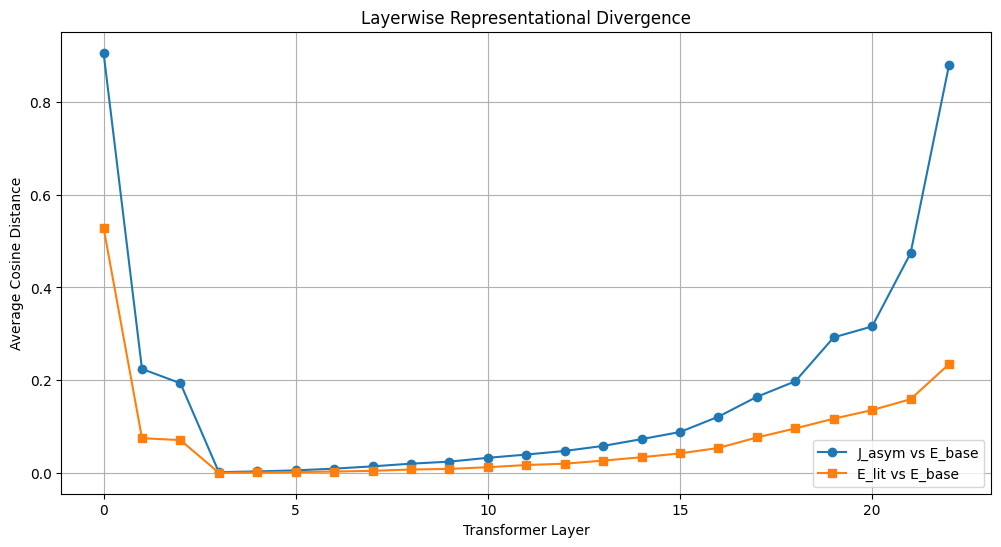

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    mean_trajectory["layer"],
    mean_trajectory["dist_asym_to_base"],
    marker='o',
    label="J_asym vs E_base"
)

plt.plot(
    mean_trajectory["layer"],
    mean_trajectory["dist_lit_to_base"],
    marker='s',
    label="E_lit vs E_base"
)

plt.xlabel("Transformer Layer")

plt.ylabel("Average Cosine Distance")

plt.title("Layerwise Representational Divergence")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
search_zone = mean_trajectory[
    mean_trajectory["layer"].between(5, 22)
]

tipping_idx = search_zone[
    "dist_asym_to_base"
].idxmin()

tipping_layer = mean_trajectory.loc[
    tipping_idx,
    "layer"
]

print("=== GEOMETRIC LOCALIZATION ===")

print(
    f"Maximum convergence occurs at Layer {tipping_layer}"
)

print(
    f"Re-expansion begins after Layer {tipping_layer}"
)

=== GEOMETRIC LOCALIZATION ===
Maximum convergence occurs at Layer 5
Re-expansion begins after Layer 5


In [ ]:
zone_df = mean_trajectory[
    mean_trajectory["layer"].between(14, 22)
].copy()

zone_df["warp_delta"] = (
    zone_df["velocity_asym"]
    -
    zone_df["velocity_control"]
)

warping_index = (
    zone_df["warp_delta"]
    .clip(lower=0)
    .sum()
)

print("=== WARPING INDEX ===")

print(
    f"W_tr = {warping_index:.6f}"
)

=== WARPING INDEX ===
W_tr = 0.612990


In [ ]:
mean_trajectory.to_csv(
    "day4_mean_trajectory.csv",
    index=False
)

print("Day 4 trajectory saved.")

Day 4 trajectory saved.


In [ ]:
df_results.to_csv(
    "hidden_state_divergence_results.csv",
    index=False
)

layer_summary.to_csv(
    "layerwise_summary.csv",
    index=False
)

print("Results saved.")

Results saved.


In [ ]:
import json

with open("japanese_asymmetry_dataset.json", "w", encoding="utf-8") as f:

    json.dump(
        dataset,
        f,
        ensure_ascii=False,
        indent=4
    )

print("Dataset JSON saved.")

Dataset JSON saved.


In [ ]:

# Triplet 3 — Ganbaru
dataset[1]["J_asym"] = "限界まで頑張り続けた。"

# Triplet 2 — Wa
dataset[2]["E_lit"] = "The team members agreed with the manager to preserve harmony during the meeting."

# Triplet 6 — Ninjo
dataset[5]["J_asym"] = "助けたかったが規則に従った。"

# Triplet 7 — Kuuki wo Yomu
dataset[6]["J_asym"] = "空気を読んで黙っていた。"

# Triplet 14 — Yugen
dataset[13]["J_asym"] = "霧の山に幽玄を感じた。"

# Triplet 18 — Kaizen
dataset[17]["E_lit"] = "Continuous improvement gradually improved the work process."

print("All final dataset fixes applied.")

All final dataset fixes applied.


In [ ]:
for i, item in enumerate(dataset):

    print(f"Index Position: {i}")
    print(f"Triplet ID: {item['id']}")
    print(f"Concept: {item['concept']}")
    print("----------------------")

Index Position: 0
Triplet ID: 1
Concept: Giri
----------------------
Index Position: 1
Triplet ID: 3
Concept: Ganbaru
----------------------
Index Position: 2
Triplet ID: 3
Concept: Ganbaru
----------------------
Index Position: 3
Triplet ID: 2
Concept: Wa
----------------------
Index Position: 4
Triplet ID: 4
Concept: Wabi-Sabi
----------------------
Index Position: 5
Triplet ID: 5
Concept: Omotenashi
----------------------
Index Position: 6
Triplet ID: 6
Concept: Ninjo
----------------------
Index Position: 7
Triplet ID: 7
Concept: Kuuki wo Yomu
----------------------
Index Position: 8
Triplet ID: 8
Concept: Ikigai
----------------------
Index Position: 9
Triplet ID: 9
Concept: Mono no Aware
----------------------
Index Position: 10
Triplet ID: 10
Concept: Tatemae
----------------------
Index Position: 11
Triplet ID: 11
Concept: Enryo
----------------------
Index Position: 12
Triplet ID: 12
Concept: Honne
----------------------
Index Position: 13
Triplet ID: 13
Concept: Shokunin Kish

In [ ]:
del dataset[2]

print("Duplicate Ganbaru removed.")

Duplicate Ganbaru removed.


In [ ]:
del dataset[8]

print("Duplicate ikigai removed.")

Duplicate ikigai removed.


In [ ]:
from transformers import AutoTokenizer

model_id = "mistralai/Mistral-7B-v0.1"

tokenizer = AutoTokenizer.from_pretrained(model_id)

print("Tokenizer loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Tokenizer loaded successfully.


In [ ]:
print(f"Total Triplets: {len(dataset)}")

Total Triplets: 21
